# Dialogue evaluation

In [2]:
from cltl.dialogue_evaluation.statistical_evaluation import StatisticalEvaluator
from cltl.dialogue_evaluation.likelihood_evaluation import LikelihoodEvaluator
from cltl.dialogue_evaluation.graph_evaluation import GraphEvaluator
from cltl.dialogue_evaluation.manual_evaluation import ManualEvaluator
import cltl.dialogue_evaluation.plot_interaction as plot

from emissor.persistence import ScenarioStorage
from emissor.persistence.persistence import ScenarioController
from emissor.processing.api import SignalProcessor
from emissor.representation.scenario import Modality, Signal

In [3]:
EMISSOR="../emissor_chat/emissor"
SCENARIO="7a201bea-3e2f-4dc2-ac36-a628ea4775cd"

In [4]:
## Statistical analysis
evaluator = StatisticalEvaluator()
evaluator.analyse_interaction_json(EMISSOR, SCENARIO)

2024-11-20 16:30:17 -     INFO -                cltl.dialogue_evaluation.StatisticalEvaluator - Booted


No location id in context
No location id in context
No location id in context
UNKNOWN annotation JSON()
UNKNOWN annotation JSON()
Saving the meta data in ../emissor_chat/emissor/7a201bea-3e2f-4dc2-ac36-a628ea4775cd/evaluation/7a201bea-3e2f-4dc2-ac36-a628ea4775cd_meta_data.json


In [6]:
## Likelihood analysis
model= "../leolani_text_to_ekg/resources/usr-topicalchat-roberta_ft"
model_name="USR"
evaluator = LikelihoodEvaluator(model=model, model_name=model_name, max_context=300, len_top_tokens=20)
evaluator.evaluate_conversation(EMISSOR, SCENARIO)

2024-11-20 16:32:14 -     INFO -                 cltl.dialogue_evaluation.LikelihoodEvaluator - Booted


----------SCENARIO:../emissor_chat/emissor, EVALUATION:likelihood metrics---------
Nr of turns: 6 Speakers: {'ACTION', 'Piek', 'Ai2Thor'} Max context: 300
Processing turn 0/5
	Calculating likelihood scores
Processing turn 1/5
	Calculating likelihood scores
Processing turn 2/5
	Calculating likelihood scores
Processing turn 3/5
	Calculating likelihood scores
Processing turn 4/5
	Calculating likelihood scores
Processing turn 5/5
	Calculating likelihood scores

	Calculating average likelihood scores
		Processing speaker ACTION/2
		Processing speaker Piek/2
		Processing speaker Ai2Thor/2

	Saved to file: ../emissor_chat/emissor/7a201bea-3e2f-4dc2-ac36-a628ea4775cd/evaluation/likelihood_evaluation_USR_context300.csv

	Saved to file: ../emissor_chat/emissor/7a201bea-3e2f-4dc2-ac36-a628ea4775cd/evaluation/likelihood_evaluation_USR_context300_overall.csv


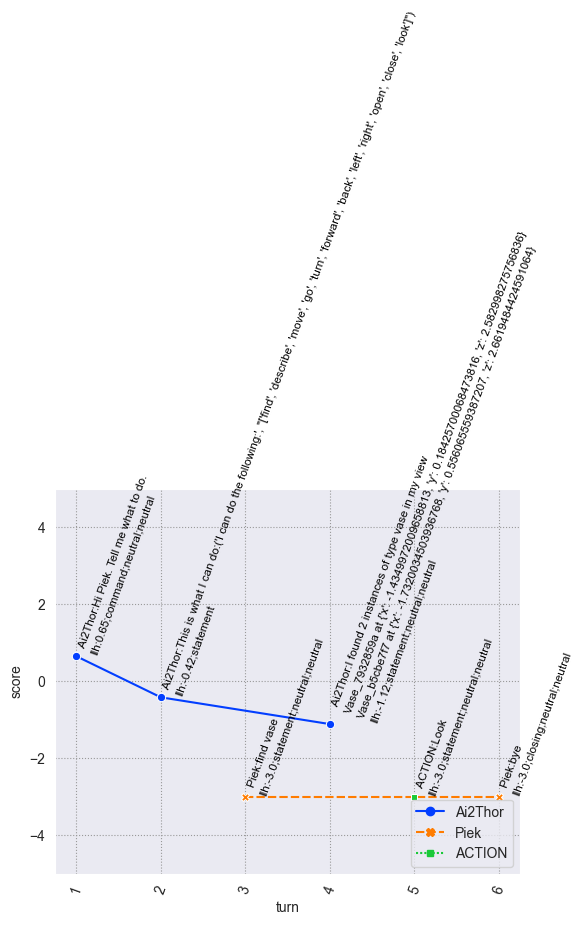

In [8]:
## Plot analysis

settings = plot.PlotSettings()
settings._ANNOTATIONS = 'go,sentiment,llh'
settings._SENTIMENT_THRESHOLD=0.7
settings._LLH_THRESHOLD=0.3


scenario_storage = ScenarioStorage(EMISSOR)
scenario_ctrl = scenario_storage.load_scenario(SCENARIO)
speaker = scenario_ctrl.scenario.context.speaker["name"]
agent = scenario_ctrl.scenario.context.agent["name"]
text_signals = scenario_ctrl.get_signals(Modality.TEXT)

plot.create_timeline_image(scenario_path=EMISSOR, 
                           scenario=SCENARIO,
                           speaker=speaker, 
                           agent=agent,
                           signals=text_signals, 
                           settings=settings)

## Graph analysis

In [12]:
import os

scenario_path = os.path.join(EMISSOR, SCENARIO)
rdf_path = os.path.join(scenario_path, "rdf")
if os.path.exists(rdf_path):
    evaluator = GraphEvaluator()
    evaluator.evaluate_conversation(scenario_path, rdf_folder=rdf_path)
else:
    print("No triples found for", SCENARIO)

No triples found for 7a201bea-3e2f-4dc2-ac36-a628ea4775cd


## Manual evaluation

In [14]:
evaluator = ManualEvaluator()
evaluator.evaluate_conversation(EMISSOR, SCENARIO)

2024-11-20 16:41:21 -     INFO -                     cltl.dialogue_evaluation.ManualEvaluator - Booted


SCENARIO_FOLDER: ../emissor_chat/emissor
Nr of turns: 6  extracted from scenario:  7a201bea-3e2f-4dc2-ac36-a628ea4775cd
Speakers: {'ACTION', 'Piek', 'Ai2Thor'}
	Placeholders for manual scores
